<a href="https://colab.research.google.com/github/HaneenFDalvi/17_HaneenDalvi_Assignment1/blob/main/DAV_ASSIGNMENT1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

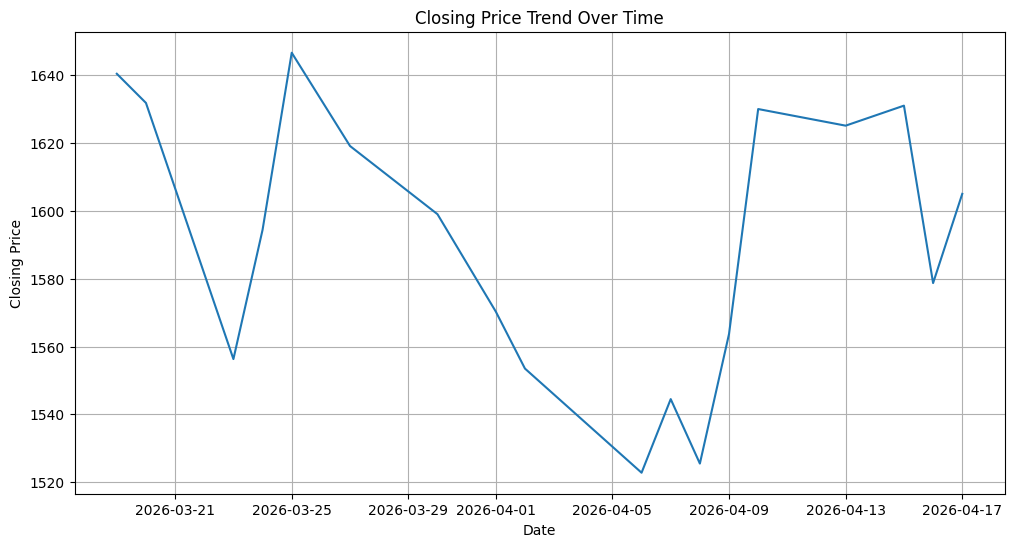

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("/content/Quote-Equity-ASTRAL-EQ-19-03-2026-19-04-2026.csv")

# remove spaces from column names
df.columns = df.columns.str.strip()

# convert DATE column
df['DATE'] = pd.to_datetime(df['DATE'], errors='coerce')

# convert CLOSE column properly
df['CLOSE'] = df['CLOSE'].astype(str).str.replace(',', '')
df['CLOSE'] = pd.to_numeric(df['CLOSE'], errors='coerce')

# drop missing values
df = df.dropna(subset=['DATE', 'CLOSE'])

# sort by date
df = df.sort_values('DATE')

# plot
plt.figure(figsize=(12,6))
plt.plot(df['DATE'], df['CLOSE'])
plt.title("Closing Price Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.grid(True)
plt.show()

========== ADF TEST (Original Data) ==========
ADF Statistic: -1.7046661039171704
p-value: 0.42870997754525136
❌ Series is NOT Stationary (Fail to Reject H0)

========== ADF TEST (After Differencing) ==========
ADF Statistic: -3.8365141056101346
p-value: 0.0025550604965952346
✅ Differenced Series is Stationary

Using lags for ACF = 16
Using lags for PACF = 7


<Figure size 1000x500 with 0 Axes>

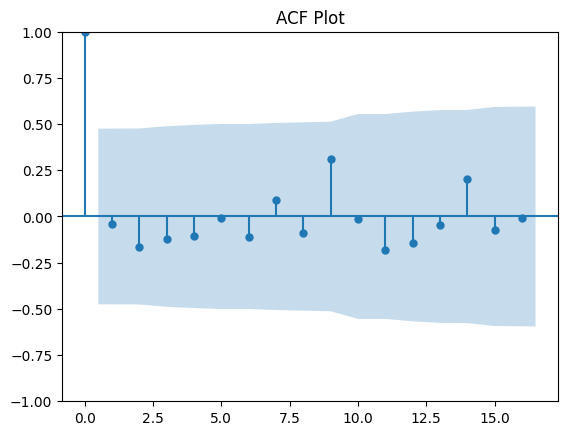

<Figure size 1000x500 with 0 Axes>

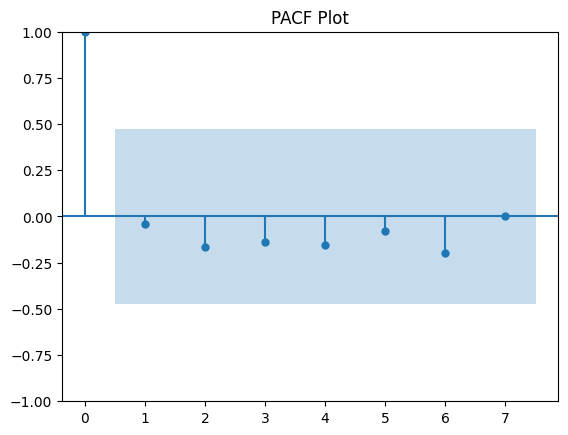

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/p


========== ARIMA MODEL SUMMARY ==========
                               SARIMAX Results                                
Dep. Variable:                  CLOSE   No. Observations:                   14
Model:                 ARIMA(1, 1, 1)   Log Likelihood                 -65.480
Date:                Sun, 19 Apr 2026   AIC                            136.959
Time:                        20:05:27   BIC                            138.654
Sample:                             0   HQIC                           136.611
                                 - 14                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.7074      0.823     -0.860      0.390      -2.320       0.906
ma.L1          0.9948     13.776      0.072      0.942     -26.005      27.994
sigma2   

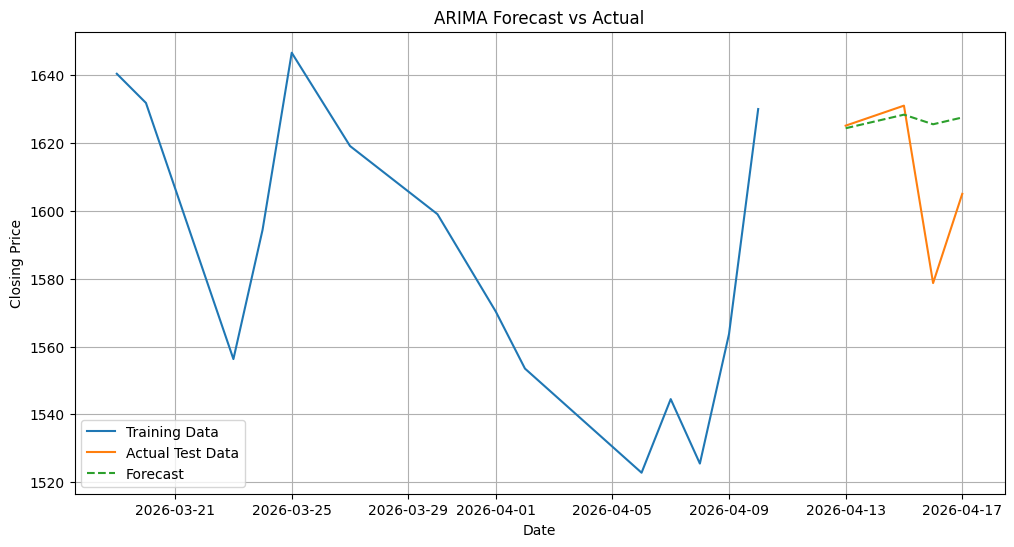

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA

from sklearn.metrics import mean_absolute_error, mean_squared_error

# -----------------------------
# Load Dataset
# -----------------------------
df = pd.read_csv("Quote-Equity-ASTRAL-EQ-19-03-2026-19-04-2026.csv")

# Remove spaces from column names
df.columns = df.columns.str.strip()

# Convert DATE and CLOSE
df['DATE'] = pd.to_datetime(df['DATE'], errors='coerce')
df['CLOSE'] = df['CLOSE'].astype(str).str.replace(',', '')
df['CLOSE'] = pd.to_numeric(df['CLOSE'], errors='coerce')

# Drop missing and sort
df = df.dropna(subset=['DATE', 'CLOSE'])
df = df.sort_values('DATE')

# Set DATE as index
df.set_index('DATE', inplace=True)

# Time series
ts = df['CLOSE']

# -----------------------------
# (a) ADF Test
# -----------------------------
print("========== ADF TEST (Original Data) ==========")
adf_result = adfuller(ts)

print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])

if adf_result[1] <= 0.05:
    print("✅ Series is Stationary (Reject H0)")
else:
    print("❌ Series is NOT Stationary (Fail to Reject H0)")

# Differencing (for stationarity)
ts_diff = ts.diff().dropna()

print("\n========== ADF TEST (After Differencing) ==========")
adf_result_diff = adfuller(ts_diff)

print("ADF Statistic:", adf_result_diff[0])
print("p-value:", adf_result_diff[1])

if adf_result_diff[1] <= 0.05:
    print("✅ Differenced Series is Stationary")
else:
    print("❌ Differenced Series is still NOT Stationary")

# -----------------------------
# (b) ACF and PACF plots (FIXED LAGS)
# -----------------------------
# Adjust lags for PACF to be less than half the sample size
lags_value = min(30, len(ts_diff) - 1)
# For PACF, lags must be < len(series) / 2
pacf_lags_value = min(lags_value, int(len(ts_diff) / 2) -1)

print("\nUsing lags for ACF =", lags_value)
print("Using lags for PACF =", pacf_lags_value)

plt.figure(figsize=(10,5))
plot_acf(ts_diff, lags=lags_value)
plt.title("ACF Plot")
plt.show()

plt.figure(figsize=(10,5))
plot_pacf(ts_diff, lags=pacf_lags_value) # Use adjusted lags for PACF
plt.title("PACF Plot")
plt.show()

# -----------------------------
# (c) Fit ARIMA model and Evaluate
# -----------------------------

# Train-Test Split (80-20)
train_size = int(len(ts) * 0.8)
train, test = ts[:train_size], ts[train_size:]

# Choose ARIMA Parameters (edit after seeing ACF/PACF)
p, d, q = 1, 1, 1

model = ARIMA(train, order=(p, d, q))
model_fit = model.fit()

print("\n========== ARIMA MODEL SUMMARY ==========")
print(model_fit.summary())

# Forecasting
forecast = model_fit.forecast(steps=len(test))

# Evaluation
mae = mean_absolute_error(test, forecast)
mse = mean_squared_error(test, forecast)
rmse = np.sqrt(mse)

print("\n========== MODEL PERFORMANCE ==========")
print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)

# Plot forecast vs actual
plt.figure(figsize=(12,6))
plt.plot(train.index, train, label="Training Data")
plt.plot(test.index, test, label="Actual Test Data")
plt.plot(test.index, forecast, label="Forecast", linestyle="--")

plt.title("ARIMA Forecast vs Actual")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.legend()
plt.grid(True)
plt.show()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/p

Next 30 Days Forecasted Closing Prices:

2026-04-18    1601.841469
2026-04-19    1599.802065
2026-04-20    1598.485261
2026-04-21    1597.635025
2026-04-22    1597.086044
2026-04-23    1596.731577
2026-04-24    1596.502705
2026-04-25    1596.354926
2026-04-26    1596.259508
2026-04-27    1596.197899
2026-04-28    1596.158119
2026-04-29    1596.132433
2026-04-30    1596.115849
2026-05-01    1596.105141
2026-05-02    1596.098227
2026-05-03    1596.093762
2026-05-04    1596.090880
2026-05-05    1596.089019
2026-05-06    1596.087817
2026-05-07    1596.087041
2026-05-08    1596.086540
2026-05-09    1596.086216
2026-05-10    1596.086007
2026-05-11    1596.085873
2026-05-12    1596.085786
2026-05-13    1596.085729
2026-05-14    1596.085693
2026-05-15    1596.085670
2026-05-16    1596.085654
2026-05-17    1596.085645
Freq: D, dtype: float64


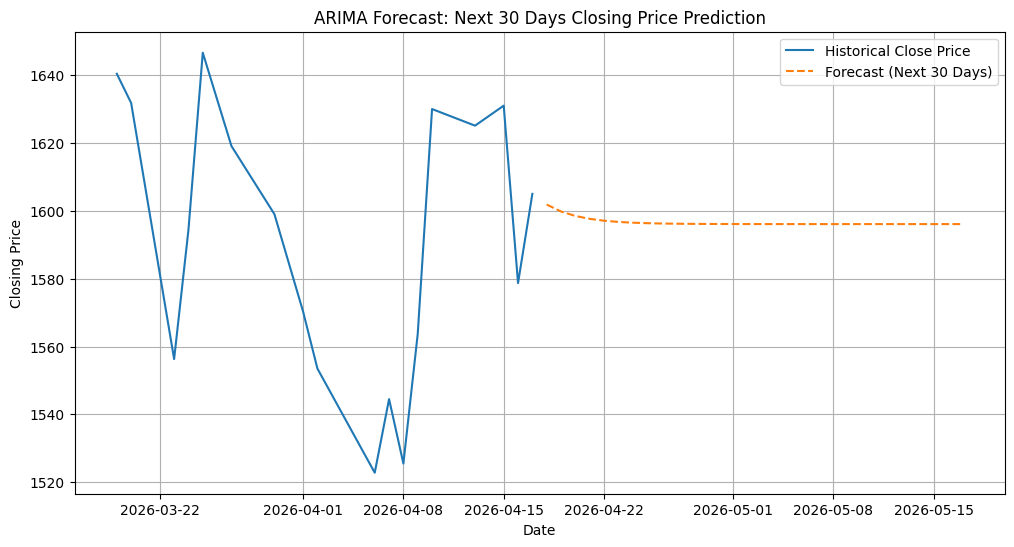

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA

# -----------------------------
# Load Dataset
# -----------------------------
df = pd.read_csv("Quote-Equity-ASTRAL-EQ-19-03-2026-19-04-2026.csv")

df.columns = df.columns.str.strip()

df['DATE'] = pd.to_datetime(df['DATE'], errors='coerce')
df['CLOSE'] = df['CLOSE'].astype(str).str.replace(',', '')
df['CLOSE'] = pd.to_numeric(df['CLOSE'], errors='coerce')

df = df.dropna(subset=['DATE', 'CLOSE'])
df = df.sort_values('DATE')
df.set_index('DATE', inplace=True)

ts = df['CLOSE']

# -----------------------------
# Train ARIMA Model
# -----------------------------
p, d, q = 1, 1, 1   # change if needed
model = ARIMA(ts, order=(p, d, q))
model_fit = model.fit()

# -----------------------------
# (a) Forecast Next 30 Days
# -----------------------------
forecast_steps = 30
forecast = model_fit.forecast(steps=forecast_steps)

# Create future dates
future_dates = pd.date_range(start=ts.index[-1] + pd.Timedelta(days=1),
                             periods=forecast_steps, freq='D')

forecast_series = pd.Series(forecast.values, index=future_dates)

print("Next 30 Days Forecasted Closing Prices:\n")
print(forecast_series)

# -----------------------------
# (b) Plot Historical + Forecast
# -----------------------------
plt.figure(figsize=(12,6))
plt.plot(ts, label="Historical Close Price")
plt.plot(forecast_series, label="Forecast (Next 30 Days)", linestyle="--")

plt.title("ARIMA Forecast: Next 30 Days Closing Price Prediction")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
# -----------------------------
# Trend Interpretation
# -----------------------------
start_price = forecast_series.iloc[0]
end_price = forecast_series.iloc[-1]

change = end_price - start_price
percent_change = (change / start_price) * 100

print("\n----- Trend Interpretation -----")
print("Start Forecast Price:", start_price)
print("End Forecast Price:", end_price)
print("Change:", change)
print("Percentage Change:", percent_change, "%")

if percent_change > 2:
    print("📈 Expected Trend: Upward Trend (Price Increasing)")
elif percent_change < -2:
    print("📉 Expected Trend: Downward Trend (Price Decreasing)")
else:
    print("➡️ Expected Trend: Stability (No Major Change)")


----- Trend Interpretation -----
Start Forecast Price: 1601.8414690383615
End Forecast Price: 1596.0856446259163
Change: -5.755824412445236
Percentage Change: -0.3593254715712066 %
➡️ Expected Trend: Stability (No Major Change)
